In [ ]:
from google.colab import files
uploaded=files.upload()

Saving python data.xlsx to python data.xlsx


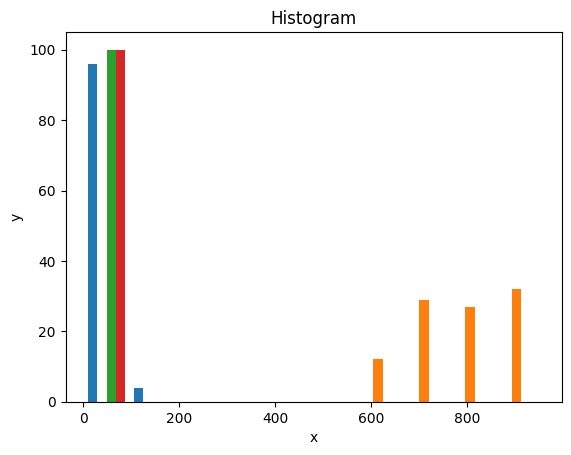

Original DataFrame shape: (100, 4)
Training DataFrame shape: (80, 4)
Testing DataFrame shape: (20, 4)

First 5 rows of Training Data:


,S.No,RAINFALL,TEMPERATRE,YIELD(Kg/ha)
0,1,820,24.5,3.8
1,2,760,25.2,3.5
2,3,910,23.8,4.1
3,4,650,27.1,3.0
4,5,720,26.4,3.2



First 5 rows of Testing Data:


,S.No,RAINFALL,TEMPERATRE,YIELD(Kg/ha)
80,81,780,25.4,3.6
81,82,900,24.0,4.1
82,83,680,27.6,2.9
83,84,750,26.2,3.3
84,85,820,24.8,3.8


    S.No  RAINFALL  TEMPERATRE  YIELD(Kg/ha)
0      1       820        24.5           3.8
1      2       760        25.2           3.5
2      3       910        23.8           4.1
3      4       650        27.1           3.0
4      5       720        26.4           3.2
..   ...       ...         ...           ...
75    76       870        24.2           4.0
76    77       945        23.4           4.3
77    78       620        28.3           2.6
78    79       710        26.9           3.1
79    80       860        24.5           3.9

[80 rows x 4 columns]
    S.No  RAINFALL  TEMPERATRE  YIELD(Kg/ha)
80    81       780        25.4           3.6
81    82       900        24.0           4.1
82    83       680        27.6           2.9
83    84       750        26.2           3.3
84    85       820        24.8           3.8
85    86       890        24.1           4.0
86    87       960        23.3           4.5
87    88       640        28.0           2.7
88    89       720        26.6  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel('python data.xlsx')

plt.hist(df)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Histogram")
plt.show()

train_size = int(0.8 * len(df))

train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

print(f"Original DataFrame shape: {df.shape}")
print(f"Training DataFrame shape: {train_df.shape}")
print(f"Testing DataFrame shape: {test_df.shape}")

print("\nFirst 5 rows of Training Data:")
display(train_df.head())

print("\nFirst 5 rows of Testing Data:")
display(test_df.head())

print(train_df)
print(test_df)

In [ ]:
from sklearn.model_selection import train_test_split
X= df[["RAINFALL", "TEMPERATRE"]]
y= df["YIELD(Kg/ha)"]

X_train,X_temp,y_train,y_temp= train_test_split(X,y,test_size=0.40)

X_val,X_test,y_val,y_test= train_test_split(X_temp,y_temp,test_size=0.70)

print("Training set:",X_train.shape)
print("Validation set:",X_val.shape)
print("Test set:",X_test.shape)



Training set: (60, 2)
Validation set: (12, 2)
Test set: (28, 2)


In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)


from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

def evaluate_model(X,y,name):
  y_pred= model.predict(X)
  mae=mean_absolute_error(y,y_pred)
  mse=mean_squared_error(y,y_pred)
  rmse=np.sqrt(mse)
  r2=r2_score(y,y_pred)

  print(f"\n{name} SET PERFORMANCE")
  print("MAE:",mae)
  print("MSE:",mse)
  print("RMSE:",rmse)
  print("R2:",r2)

evaluate_model(X_train,y_train,"Training")
evaluate_model(X_val,y_val,"Validation")
evaluate_model(X_test,y_test,"Test")


Training SET PERFORMANCE
MAE: 0.05137847167456622
MSE: 0.004956011718128202
RMSE: 0.07039894685382873
R2: 0.9798942492193269

Validation SET PERFORMANCE
MAE: 0.06788794799665177
MSE: 0.006244935072745887
RMSE: 0.07902490159909019
R2: 0.9784450946674159

Test SET PERFORMANCE
MAE: 0.05444118230484908
MSE: 0.004363531180361995
RMSE: 0.06605702975733918
R2: 0.9818446720511393


In [ ]:
from sklearn.model_selection import cross_val_score
def cross_validation_results(k):
  scores=cross_val_score(model,X,y,
  scoring="neg_mean_squared_error",cv=k)
  rmse_scores=np.sqrt(-scores)

  print(f"\n-Fold Cross Validation Results")
  print("RMSE per fold:",rmse_scores)
  print("Average RMSE:",rmse_scores.mean())
  print("Std Dev RMSE:",rmse_scores.std())

for k in [4,12,4]:
  cross_validation_results(k)



-Fold Cross Validation Results
RMSE per fold: [0.08363163 0.05749465 0.06133109 0.18659753]
Average RMSE: 0.09726372648203174
Std Dev RMSE: 0.05253355092271366

-Fold Cross Validation Results
RMSE per fold: [0.10785288 0.05175242 0.05724065 0.06787206 0.05696806 0.03581551
 0.06523967 0.05425913 0.05538964 0.07367975 0.08326642 0.33784309]
Average RMSE: 0.08726493949284025
Std Dev RMSE: 0.07751772638060969

-Fold Cross Validation Results
RMSE per fold: [0.08363163 0.05749465 0.06133109 0.18659753]
Average RMSE: 0.09726372648203174
Std Dev RMSE: 0.05253355092271366
